In [16]:
# Clusting

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [18]:

X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=4, random_state=42)

In [19]:

df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [20]:
df

,Feature_1,Feature_2
0,-2.282534,-9.692815
1,-6.147668,1.755990
2,13.399091,-1.260023
3,-4.077630,3.160226
4,9.444735,0.340868
...,...,...
495,-1.282205,-3.181575
496,-2.817604,10.378894
497,3.296740,8.649256
498,-8.970519,-2.684073


In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


In [22]:
inertia = []
K_range = range(1, 11)


In [23]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


In [24]:

inertia

[999.9999999999994,
 528.8064432605643,
 294.4377068678185,
 250.4552469653445,
 216.88110656982604,
 185.27440675195913,
 156.70879996290438,
 135.62603453115264,
 129.1039634823981,
 119.94101297104991]

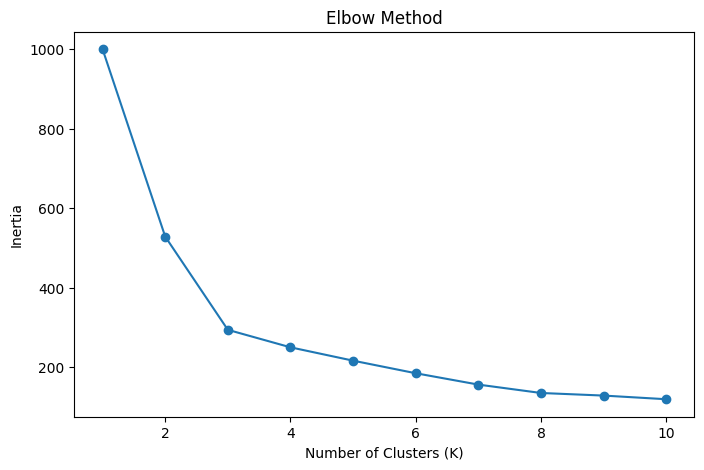

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# Save image
plt.savefig('elbow_method.png', dpi=300, bbox_inches='tight')

plt.show()

In [26]:

kmeans_final = KMeans(n_clusters=3, random_state=42)

In [27]:

cluster_labels = kmeans_final.fit_predict(X_scaled)

In [28]:
df['cluster'] = cluster_labels

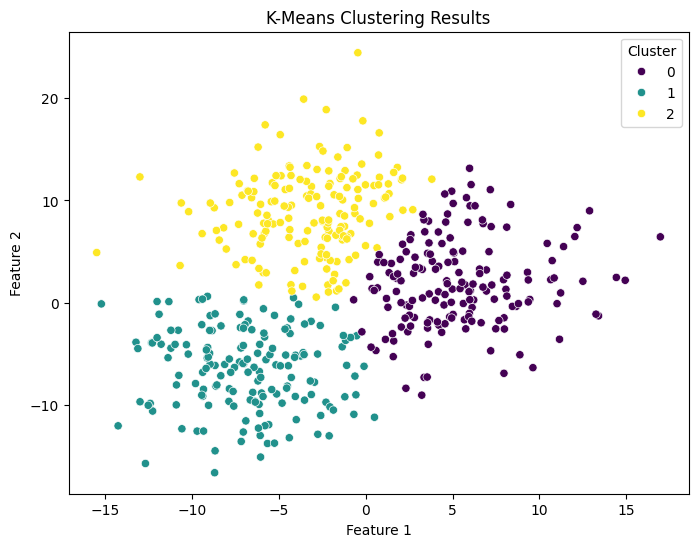

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Feature_1'],
    y=df['Feature_2'],
    hue=df['cluster'],
    palette='viridis'
)

plt.title('K-Means Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(title='Cluster')

# Save the plot
plt.savefig('kmeans_clusters.png', dpi=300, bbox_inches='tight')

plt.show()

In [30]:

from sklearn.datasets import make_moons

In [31]:
X, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

In [32]:
from sklearn.cluster import KMeans, DBSCAN

In [33]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [35]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)


In [36]:
df['kmeans_cluster'] = kmeans_labels

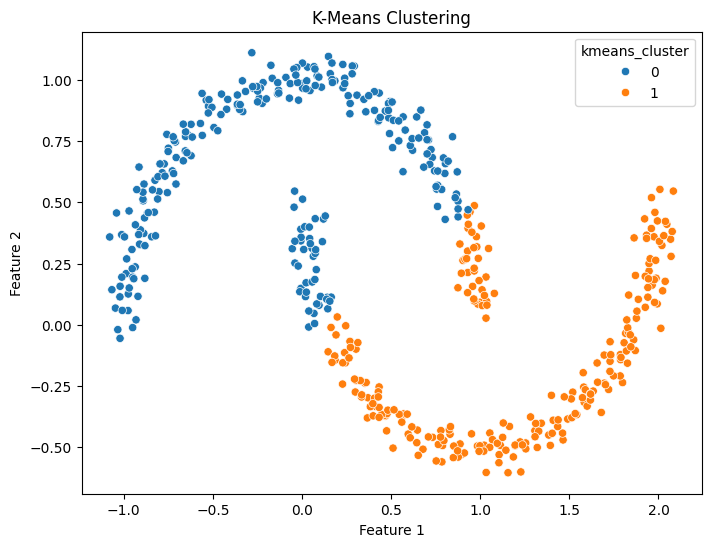

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Feature_1'],
    y=df['Feature_2'],
    hue=df['kmeans_cluster'],
    palette='tab10'
)

plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Save image
plt.savefig('kmeans_scatterplot.png', dpi=300, bbox_inches='tight')

plt.show()

In [38]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [39]:
df['dbscan_cluster'] = dbscan_labels

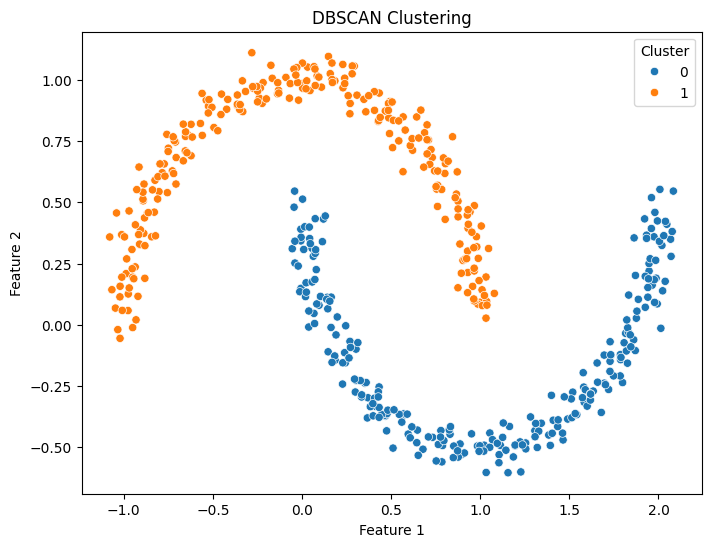

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Feature_1'],
    y=df['Feature_2'],
    hue=df['dbscan_cluster'],
    palette='tab10'
)

plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(title='Cluster')

# Save as HD image
plt.savefig('dbscan_clustering.png', dpi=300, bbox_inches='tight')

plt.show()